# Data & Model Drift Monitoring

## Objective

The earlier stages of this project established a reproducible feature pipeline, uplift model, treatment-decision engine, MLflow tracking, API serving layer, orchestration, incremental ingestion, continuous integration, and event-stream processing.

A model can remain technically available while the population it receives changes substantially from the population used during development.

In this notebook, I build a monitoring framework for detecting changes in model inputs, predicted uplift, and downstream decision behavior.

I compare the model-development population with the X5 scoring population using Population Stability Index (PSI), Standardized Mean Difference (SMD), and changes in missingness.

I then create a deliberately shifted synthetic population to verify that the monitoring logic detects a known distribution change.

Because the X5 scoring dataset does not contain observed treatment outcomes, this notebook does not measure post-deployment uplift-model performance. It monitors population and prediction stability rather than realized causal performance.

## 1. Monitoring populations

I use the model-development feature population as the monitoring reference.

The separate X5 scoring feature population represents the population currently presented to the model.

These datasets are useful for demonstrating a monitoring framework, but they are not a genuine chronological production comparison. Therefore, differences between them should not automatically be interpreted as real-world temporal drift.

Only features consumed by the model are included in the feature-drift report. Customer identifiers, treatment assignments, and observed outcomes are excluded.

In [1]:
# ============================================================
# Load reference and current feature populations
#
# Reference:
#   MART_UPLIFT_TRAINING
#
# Current:
#   MART_UPLIFT_SCORING
#
# Both were previously extracted from Snowflake and cached
# locally as Parquet files.
# ============================================================

from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd


PROJECT_ROOT = next(
    path
    for path in [
        Path.cwd(),
        *Path.cwd().parents,
    ]
    if (
        path
        / "dbt"
        / "dbt_project.yml"
    ).exists()
)

sys.path.insert(
    0,
    str(PROJECT_ROOT),
)


REFERENCE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "mart_uplift_training.parquet"
)

CURRENT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "mart_uplift_scoring.parquet"
)


reference_df = pd.read_parquet(
    REFERENCE_PATH
)

current_df = pd.read_parquet(
    CURRENT_PATH
)


print(
    "Reference rows:",
    f"{len(reference_df):,}",
)

print(
    "Current rows:",
    f"{len(current_df):,}",
)

print(
    "Reference columns:",
    len(reference_df.columns),
)

print(
    "Current columns:",
    len(current_df.columns),
)

Reference rows: 200,039
Current rows: 200,123
Reference columns: 37
Current columns: 35


In [2]:
# ============================================================
# Load the trusted local Notebook 05 model artifact
#
# joblib artifacts can execute Python code while loading.
# Only load the artifact created by this project.
# ============================================================

MODEL_PATH = (
    PROJECT_ROOT
    / "data"
    / "models"
    / "logistic_t_learner_full.joblib"
)

model_bundle = joblib.load(
    MODEL_PATH
)


print(
    "Artifact type:",
    type(model_bundle),
)

if isinstance(
    model_bundle,
    dict,
):

    print(
        "Artifact keys:",
        sorted(
            model_bundle.keys()
        ),
    )

Artifact type: <class 'dict'>
Artifact keys: ['control_model', 'feature_columns', 'feature_cutoff', 'model_family', 'training_customers', 'treatment_model']


In [3]:
# ============================================================
# Extract the treatment and control pipelines
#
# The project stores two independent models:
#
# treatment model:
#     estimates P(Y=1 | X, treatment)
#
# control model:
#     estimates P(Y=1 | X, control)
#
# predicted uplift:
#
#     p_treatment - p_control
#
# The helper supports the common names used by the project's
# earlier modeling/export code and fails explicitly if the
# artifact structure is not recognized.
# ============================================================

def first_available(
    mapping,
    candidates,
):

    for candidate in candidates:

        if candidate in mapping:

            return mapping[
                candidate
            ]

    return None


if isinstance(
    model_bundle,
    dict,
):

    treatment_model = first_available(
        model_bundle,
        [
            "treatment_model",
            "treatment_pipeline",
            "model_treatment",
        ],
    )

    control_model = first_available(
        model_bundle,
        [
            "control_model",
            "control_pipeline",
            "model_control",
        ],
    )

else:

    treatment_model = getattr(
        model_bundle,
        "treatment_model",
        None,
    )

    control_model = getattr(
        model_bundle,
        "control_model",
        None,
    )


if (
    treatment_model is None
    or control_model is None
):

    raise RuntimeError(
        "The Notebook 05 model artifact "
        "structure was not recognized. "
        "Inspect the artifact keys printed above "
        "before changing any monitoring logic."
    )


# ------------------------------------------------------------
# Recover the model's expected feature columns.
#
# sklearn Pipeline objects preserve feature_names_in_
# when they were fitted on a pandas dataframe.
# ------------------------------------------------------------

if isinstance(
    model_bundle,
    dict,
):

    feature_columns = first_available(
        model_bundle,
        [
            "feature_columns",
            "features",
            "model_features",
        ],
    )

else:

    feature_columns = getattr(
        model_bundle,
        "feature_columns",
        None,
    )


if feature_columns is None:

    feature_columns = getattr(
        treatment_model,
        "feature_names_in_",
        None,
    )


if feature_columns is None:

    raise RuntimeError(
        "Could not recover the model feature "
        "contract from the trusted artifact."
    )


feature_columns = list(
    feature_columns
)


print(
    "Model features:",
    len(feature_columns),
)

print(
    feature_columns
)

Model features: 34
['age', 'gender', 'customer_tenure_days', 'redeemed_before_cutoff_flag', 'transaction_count', 'recency_days', 'active_history_days', 'total_purchase_value', 'avg_basket_value', 'median_basket_value', 'basket_value_stddev', 'max_basket_value', 'distinct_store_count', 'transaction_count_30d', 'purchase_value_30d', 'transaction_count_prior_30d', 'purchase_value_prior_30d', 'transaction_30d_pct', 'purchase_value_30d_pct', 'total_regular_points_received', 'total_express_points_received', 'total_regular_points_redeemed', 'total_express_points_redeemed', 'redemption_transaction_count', 'redemption_transaction_pct', 'item_line_count', 'distinct_product_count', 'distinct_level1_category_count', 'total_product_units', 'own_trademark_item_pct', 'alcohol_item_pct', 'category_e344ab2e71_item_pct', 'category_c3d3a8e8c6_item_pct', 'category_ec62ce61e3_item_pct']


In [4]:
# ============================================================
# Compare reference and current feature populations
# ============================================================

from src.drift_monitoring import (
    build_feature_drift_report,
)


feature_drift = (
    build_feature_drift_report(
        reference_df,
        current_df,
        feature_columns,
    )
)


display(
    feature_drift.round(
        {
            "psi": 4,
            "smd": 4,
            "reference_missing_pct": 2,
            "current_missing_pct": 2,
            "missingness_delta_pp": 2,
        }
    )
)

,feature,feature_type,psi,smd,reference_missing_pct,current_missing_pct,missingness_delta_pp,alert
0,transaction_count_prior_30d,numeric,0.0002,-0.0007,0.00,0.00,0.00,OK
1,category_e344ab2e71_item_pct,numeric,0.0001,-0.0005,0.00,0.00,0.00,OK
2,active_history_days,numeric,0.0001,-0.0067,0.00,0.00,0.00,OK
3,category_ec62ce61e3_item_pct,numeric,0.0001,-0.0049,0.00,0.00,0.00,OK
4,transaction_count,numeric,0.0001,-0.0018,0.00,0.00,0.00,OK
5,transaction_30d_pct,numeric,0.0001,0.0004,0.00,0.00,0.00,OK
6,own_trademark_item_pct,numeric,0.0001,-0.0011,0.00,0.00,0.00,OK
7,distinct_product_count,numeric,0.0001,0.0011,0.00,0.00,0.00,OK
8,purchase_value_30d_pct,numeric,0.0001,0.0019,0.00,0.00,0.00,OK
9,total_regular_points_received,numeric,0.0001,0.0007,0.00,0.00,0.00,OK


In [5]:
# ============================================================
# Monitoring alert summary
# ============================================================

alert_summary = (
    feature_drift[
        "alert"
    ]
    .value_counts()
    .reindex(
        [
            "CRITICAL",
            "WARNING",
            "OK",
        ],
        fill_value=0,
    )
    .rename_axis(
        "alert"
    )
    .reset_index(
        name="features"
    )
)

display(
    alert_summary
)


print(
    "\nHighest PSI features:"
)

display(
    feature_drift[
        [
            "feature",
            "feature_type",
            "psi",
            "smd",
            "missingness_delta_pp",
            "alert",
        ]
    ]
    .sort_values(
        "psi",
        ascending=False,
    )
    .head(10)
)

,alert,features
0,CRITICAL,0
1,WARNING,0
2,OK,34



Highest PSI features:


,feature,feature_type,psi,smd,missingness_delta_pp,alert
0,transaction_count_prior_30d,numeric,0.000204,-0.000659,0.0,OK
1,category_e344ab2e71_item_pct,numeric,0.000143,-0.000463,0.0,OK
2,active_history_days,numeric,0.000133,-0.006675,0.0,OK
3,category_ec62ce61e3_item_pct,numeric,0.000120,-0.004933,0.0,OK
4,transaction_count,numeric,0.000112,-0.001792,0.0,OK
5,transaction_30d_pct,numeric,0.000101,0.000416,0.0,OK
6,own_trademark_item_pct,numeric,0.000100,-0.001109,0.0,OK
7,distinct_product_count,numeric,0.000093,0.001122,0.0,OK
8,purchase_value_30d_pct,numeric,0.000084,0.001857,0.0,OK
9,total_regular_points_received,numeric,0.000080,0.000671,0.0,OK


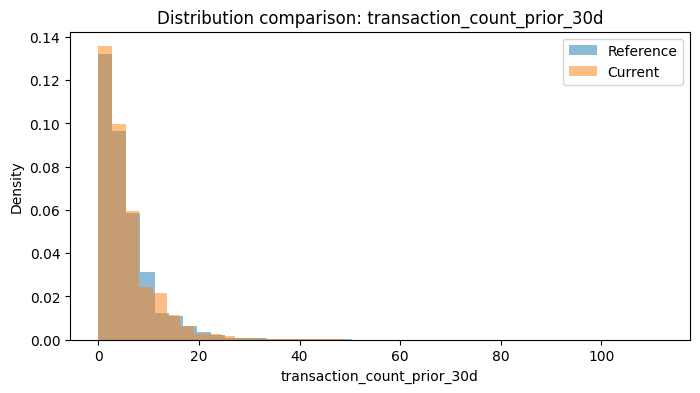

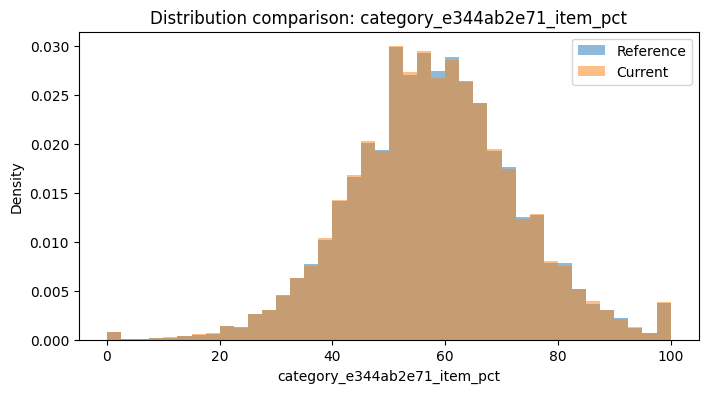

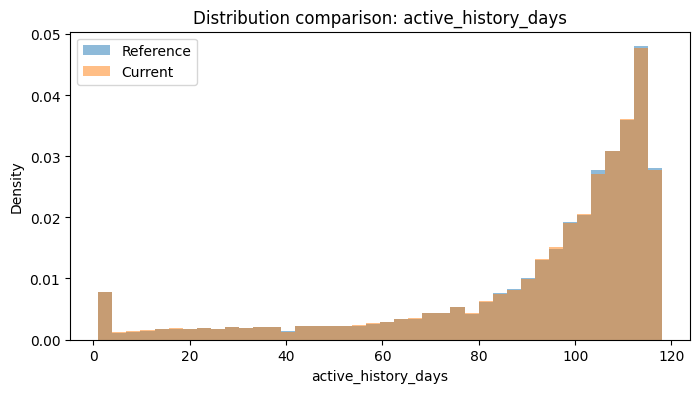

In [6]:
# ============================================================
# Plot distributions for the highest-PSI numeric features
#
# PSI tells us which features moved.
#
# The plots help explain HOW those distributions moved.
# ============================================================

import matplotlib.pyplot as plt


top_numeric_features = (
    feature_drift.loc[
        feature_drift[
            "feature_type"
        ] == "numeric"
    ]
    .sort_values(
        "psi",
        ascending=False,
    )
    .head(3)[
        "feature"
    ]
    .tolist()
)


for feature in top_numeric_features:

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    ax.hist(
        reference_df[
            feature
        ].dropna(),
        bins=40,
        density=True,
        alpha=0.5,
        label="Reference",
    )

    ax.hist(
        current_df[
            feature
        ].dropna(),
        bins=40,
        density=True,
        alpha=0.5,
        label="Current",
    )

    ax.set_title(
        f"Distribution comparison: {feature}"
    )

    ax.set_xlabel(
        feature
    )

    ax.set_ylabel(
        "Density"
    )

    ax.legend()

    plt.show()

In [7]:
# ============================================================
# Score both populations using the SAME deployed model
#
# IMPORTANT:
#
# These predictions are being used for distribution
# monitoring, not model-performance evaluation.
#
# The reference predictions are partly in-sample because the
# full-data model was fitted on the training population.
#
# That is acceptable for establishing a monitoring baseline,
# but it must not be interpreted as independent validation.
# ============================================================

X_reference = (
    reference_df[
        feature_columns
    ]
)

X_current = (
    current_df[
        feature_columns
    ]
)


reference_p_treatment = (
    treatment_model
    .predict_proba(
        X_reference
    )[:, 1]
)

reference_p_control = (
    control_model
    .predict_proba(
        X_reference
    )[:, 1]
)

reference_uplift = (
    reference_p_treatment
    - reference_p_control
)


current_p_treatment = (
    treatment_model
    .predict_proba(
        X_current
    )[:, 1]
)

current_p_control = (
    control_model
    .predict_proba(
        X_current
    )[:, 1]
)

current_uplift = (
    current_p_treatment
    - current_p_control
)


print(
    "Reference uplift mean:",
    f"{reference_uplift.mean():.6f}",
)

print(
    "Current uplift mean:",
    f"{current_uplift.mean():.6f}",
)

Reference uplift mean: 0.032102
Current uplift mean: 0.032054


In [ ]:
# ============================================================
# Prediction-distribution monitoring
# ============================================================

from src.drift_monitoring import (
    build_numeric_distribution_report,
)


prediction_drift = (
    build_numeric_distribution_report(
        reference_uplift,
        current_uplift,
        "predicted_uplift",
    )
)


prediction_drift_df = (
    pd.DataFrame(
        [prediction_drift]
    )
)


display(
    prediction_drift_df.round(
        6
    )
)

,metric,reference_mean,current_mean,reference_median,current_median,psi,smd,alert
0,predicted_uplift,0.032102,0.032054,0.025907,0.025935,0.000086,-0.001441,OK


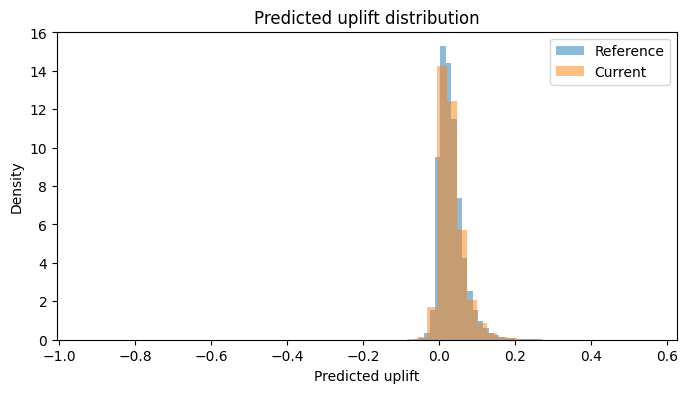

In [9]:
# ============================================================
# Predicted-uplift distribution
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.hist(
    reference_uplift,
    bins=50,
    density=True,
    alpha=0.5,
    label="Reference",
)

ax.hist(
    current_uplift,
    bins=50,
    density=True,
    alpha=0.5,
    label="Current",
)

ax.set_title(
    "Predicted uplift distribution"
)

ax.set_xlabel(
    "Predicted uplift"
)

ax.set_ylabel(
    "Density"
)

ax.legend()

plt.show()

In [ ]:
# ============================================================
# Compare downstream decision behavior
#
# build_contact_policy returns the decision dataframe.
# summarize_policy expects:
#
# 1. original score dataframe
# 2. selected client IDs
# 3. economic assumptions
# 4. a policy name
# ============================================================

from src.decisioning import (
    build_contact_policy,
    summarize_policy,
)


CONVERSION_VALUE = 20.0
CONTACT_COST = 0.25
BUDGET = 10_000.0


reference_policy = build_contact_policy(
    scores=reference_scores,
    conversion_value=CONVERSION_VALUE,
    contact_cost=CONTACT_COST,
    budget=BUDGET,
)

current_policy = build_contact_policy(
    scores=current_scores,
    conversion_value=CONVERSION_VALUE,
    contact_cost=CONTACT_COST,
    budget=BUDGET,
)


# ------------------------------------------------------------
# Extract the IDs actually selected for contact.
# ------------------------------------------------------------

reference_selected_ids = (
    reference_policy.loc[
        reference_policy["contact"],
        "client_id",
    ]
    .tolist()
)

current_selected_ids = (
    current_policy.loc[
        current_policy["contact"],
        "client_id",
    ]
    .tolist()
)


# ------------------------------------------------------------
# Summarize each policy using the same reusable Notebook 05
# decision-engine API.
# ------------------------------------------------------------

reference_summary = summarize_policy(
    scores=reference_scores,
    selected_client_ids=reference_selected_ids,
    conversion_value=CONVERSION_VALUE,
    contact_cost=CONTACT_COST,
    budget=BUDGET,
    policy_name="reference",
)

current_summary = summarize_policy(
    scores=current_scores,
    selected_client_ids=current_selected_ids,
    conversion_value=CONVERSION_VALUE,
    contact_cost=CONTACT_COST,
    budget=BUDGET,
    policy_name="current",
)


policy_comparison = pd.DataFrame(
    [
        reference_summary,
        current_summary,
    ]
).set_index(
    "policy"
)


display(
    policy_comparison
)

,contacts,contact_pct,modeled_incremental_conversions,modeled_incremental_value,contact_spend,modeled_net_value,within_budget
policy,,,,,,,
reference,40000,19.996101,3303.928870,66078.577408,10000.0,56078.577408,True
current,40000,19.987708,3291.907637,65838.152732,10000.0,55838.152732,True


## 4. Controlled drift simulation

The X5 training and scoring populations may naturally have similar feature distributions.

A monitoring system that reports little drift on similar populations is behaving appropriately, but that alone does not demonstrate that the detector can identify a meaningful distribution change.

I therefore create a controlled synthetic shift from the scoring population.

The simulation deliberately changes several model inputs while preserving the original dataset separately. These modifications are not real X5 observations and are used only to test the monitoring framework.

In [11]:
# ============================================================
# Create a controlled synthetic drift scenario
#
# We deliberately modify three known model features:
#
# - total_purchase_value
# - transaction_count_30d
# - gender
#
# The original scoring dataframe remains unchanged.
# ============================================================

synthetic_shift = (
    current_df.copy()
)


if (
    "total_purchase_value"
    in synthetic_shift.columns
):

    synthetic_shift[
        "total_purchase_value"
    ] = (
        synthetic_shift[
            "total_purchase_value"
        ]
        * 1.75
    )


if (
    "transaction_count_30d"
    in synthetic_shift.columns
):

    synthetic_shift[
        "transaction_count_30d"
    ] = (
        synthetic_shift[
            "transaction_count_30d"
        ]
        + 6
    )


if (
    "gender"
    in synthetic_shift.columns
):

    # Deterministically change the first 35% of rows.
    # No random seed is needed because the selected rows
    # are based on their existing dataframe order.

    shift_count = int(
        len(
            synthetic_shift
        )
        * 0.35
    )

    gender_index = (
        synthetic_shift.index[
            :shift_count
        ]
    )

    synthetic_shift.loc[
        gender_index,
        "gender",
    ] = "U"

In [12]:
# ============================================================
# Verify that known synthetic drift is detected
# ============================================================

synthetic_drift_report = (
    build_feature_drift_report(
        reference_df,
        synthetic_shift,
        feature_columns,
    )
)


display(
    synthetic_drift_report[
        [
            "feature",
            "psi",
            "smd",
            "missingness_delta_pp",
            "alert",
        ]
    ]
    .head(15)
    .round(4)
)

,feature,psi,smd,missingness_delta_pp,alert
0,transaction_count_30d,16.7722,1.0749,0.0,CRITICAL
1,total_purchase_value,0.3343,0.5071,0.0,CRITICAL
2,gender,0.1438,NaN,0.0,WARNING
3,transaction_count_prior_30d,0.0002,-0.0007,0.0,OK
4,category_e344ab2e71_item_pct,0.0001,-0.0005,0.0,OK
5,active_history_days,0.0001,-0.0067,0.0,OK
6,category_ec62ce61e3_item_pct,0.0001,-0.0049,0.0,OK
7,transaction_count,0.0001,-0.0018,0.0,OK
8,transaction_30d_pct,0.0001,0.0004,0.0,OK
9,own_trademark_item_pct,0.0001,-0.0011,0.0,OK


In [13]:
manipulated_features = [
    feature
    for feature in [
        "total_purchase_value",
        "transaction_count_30d",
        "gender",
    ]
    if feature
    in feature_columns
]


display(
    synthetic_drift_report[
        synthetic_drift_report[
            "feature"
        ].isin(
            manipulated_features
        )
    ].round(4)
)

,feature,feature_type,psi,smd,reference_missing_pct,current_missing_pct,missingness_delta_pp,alert
0,transaction_count_30d,numeric,16.7722,1.0749,0.0,0.0,0.0,CRITICAL
1,total_purchase_value,numeric,0.3343,0.5071,0.0,0.0,0.0,CRITICAL
2,gender,categorical,0.1438,NaN,0.0,0.0,0.0,WARNING


In [14]:
# ============================================================
# Score the deliberately shifted population
# ============================================================

X_synthetic = (
    synthetic_shift[
        feature_columns
    ]
)


synthetic_p_treatment = (
    treatment_model
    .predict_proba(
        X_synthetic
    )[:, 1]
)

synthetic_p_control = (
    control_model
    .predict_proba(
        X_synthetic
    )[:, 1]
)

synthetic_uplift = (
    synthetic_p_treatment
    - synthetic_p_control
)


synthetic_prediction_drift = (
    build_numeric_distribution_report(
        reference_uplift,
        synthetic_uplift,
        "synthetic_predicted_uplift",
    )
)


display(
    pd.DataFrame(
        [
            synthetic_prediction_drift
        ]
    ).round(6)
)

,metric,reference_mean,current_mean,reference_median,current_median,psi,smd,alert
0,synthetic_predicted_uplift,0.032102,0.03803,0.025907,0.031422,0.176619,0.180741,WARNING


In [15]:
# ============================================================
# Persist the latest monitoring report
#
# These are generated monitoring artifacts and remain outside
# Git through data/monitoring/.
# ============================================================

import json


MONITORING_DIR = (
    PROJECT_ROOT
    / "data"
    / "monitoring"
)

MONITORING_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


feature_drift.to_parquet(
    MONITORING_DIR
    / "feature_drift_report.parquet",
    index=False,
)


monitoring_summary = {
    "reference_rows":
        len(reference_df),

    "current_rows":
        len(current_df),

    "features_monitored":
        len(feature_columns),

    "critical_features":
        int(
            (
                feature_drift[
                    "alert"
                ]
                == "CRITICAL"
            ).sum()
        ),

    "warning_features":
        int(
            (
                feature_drift[
                    "alert"
                ]
                == "WARNING"
            ).sum()
        ),

    "prediction_psi":
        prediction_drift[
            "psi"
        ],

    "prediction_alert":
        prediction_drift[
            "alert"
        ],
}


with (
    MONITORING_DIR
    / "drift_summary.json"
).open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        monitoring_summary,
        file,
        indent=2,
    )


monitoring_summary

{'reference_rows': 200039,
 'current_rows': 200123,
 'features_monitored': 34,
 'critical_features': 0,
 'warning_features': 0,
 'prediction_psi': 8.582060578852685e-05,
 'prediction_alert': 'OK'}

## 5. Monitoring results

### Feature population monitoring

- Reference population: **200,039 rows**
- Current population: **200,123 rows**
- Model features monitored: **34**
- Features with OK status: **34**
- Features with WARNING status: **0**
- Features with CRITICAL status: **0**
- Highest observed feature PSI: **0.000204**
- Feature with highest PSI: **transaction_count_prior_30d**

The reference and scoring populations were extremely similar across the 34 model features. All monitored features remained below the project warning thresholds. The largest observed PSI was only 0.000204 for `transaction_count_prior_30d`.

### Prediction monitoring

- Reference mean predicted uplift: **0.032102**
- Current mean predicted uplift: **0.032054**
- Prediction PSI: **0.000086**
- Prediction drift status: **OK**

The predicted-uplift distributions were also highly stable. Mean predicted uplift changed only slightly from 0.032102 in the reference population to 0.032054 in the scoring population, and the prediction PSI remained far below the warning threshold.

### Decision-policy monitoring

Using a conversion value of **20**, contact cost of **0.25**, and budget of **10,000**:

- Reference contacts selected: **40,000**
- Current contacts selected: **40,000**
- Reference contact rate: **19.9961%**
- Current contact rate: **19.9877%**
- Reference modeled incremental conversions: **3,303.93**
- Current modeled incremental conversions: **3,291.91**
- Reference modeled incremental value: **66,078.58**
- Current modeled incremental value: **65,838.15**
- Reference modeled net value: **56,078.58**
- Current modeled net value: **55,838.15**
- Both policies remained within budget: **Yes**

The downstream treatment policy was highly stable across the two populations. Both selected 40,000 customers under the same fixed budget. The current population produced slightly lower modeled incremental conversions and modeled net value, but the overall decision behavior remained very similar.

### Controlled drift simulation

- Manipulated features: **total_purchase_value, transaction_count_30d, gender**
- Synthetic WARNING features: **1**
- Synthetic CRITICAL features: **2**
- Synthetic prediction PSI: **0.17661**
- Synthetic prediction drift status: **WARNING**

The controlled simulation successfully triggered the monitoring framework. `transaction_count_30d` produced a PSI of **16.7722** and `total_purchase_value` produced a PSI of **0.3343**, both classified as CRITICAL. `gender` produced a PSI of **0.1438**, which was classified as WARNING.

The manipulated feature distributions also propagated into the model predictions. Mean predicted uplift increased from **0.032102** to **0.038030**, and prediction PSI increased to **0.17661**, producing a WARNING-level prediction-drift alert.

### Validation

- Drift-monitoring unit tests: **4 passed**
- Full Python test suite: **18 passed**

## Conclusions and limitations

I implemented a monitoring layer for changes in model inputs, predicted uplift, and downstream treatment decisions.

The monitoring framework uses the model-development population as a reference and compares subsequent populations using Population Stability Index, Standardized Mean Difference, and changes in missingness.

I also monitor the distribution of predicted uplift because a population change may propagate through several features and become more visible in the model's final output.

Finally, I compare the downstream decision policy under the same economic assumptions to determine whether population changes materially alter the set of customers selected for treatment.

To verify that the monitoring framework can detect a known problem, I created a deliberately shifted synthetic population and reran both feature-level and prediction-level monitoring.

### Interpretation

A drift alert does not by itself mean that the model is inaccurate or should be replaced. It indicates that the population has changed enough to warrant investigation.

Likewise, an absence of detected feature drift does not prove that model performance remains stable.

True post-deployment uplift-performance monitoring would require newly observed treatment assignments and outcomes so that causal performance can be evaluated on recent data.

### Dataset limitation

The X5 training and scoring datasets are separate benchmark populations rather than a genuine chronological production history.

Therefore, comparisons between them demonstrate the monitoring framework but should not be interpreted as evidence of temporal production drift.

The synthetic drift experiment is explicitly artificial and exists only to verify detector behavior.

### Future production extensions

A production monitoring system could run these checks on a schedule, persist historical drift measurements, trigger alerts when thresholds are exceeded, compare model versions, and incorporate realized outcomes once they become available.

The current implementation establishes the reusable statistical monitoring layer required for those extensions without introducing additional monitoring infrastructure solely for demonstration purposes.